In [ ]:
pip install -r requirements.txt

In [1]:
import numpy as np
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from data_utils import AttributesDataset, ClassificationDataset, albumentation_transforms, compute_class_weights
from network.classification_net import MultiOutputModel
from solver import Solver
from vis_utils import visualize_grid

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, silhouette_score
from sklearn.manifold import TSNE

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

Train size: 11544
Val size: 2183
Center cell Img size:  torch.Size([3, 120, 120])
Full crop Img size:  torch.Size([3, 120, 120])
Concatenated Img size:  torch.Size([6, 120, 120])
------------------------------------------------------------------------
Size classes:  ['MACR' 'MICR' 'NORM']
Shape classes:  ['ACAN' 'BITE' 'ECHI' 'ELLI' 'HELM' 'NONE' 'OVAL' 'SCHI' 'SICK' 'SPHE'
 'TEAR']
Hemoglobin distribution classes:  ['HYPO' 'HYPR' 'NONE' 'STOM' 'TARG']
Inclusion classes:  ['BAST', 'HOJO', 'MALA', 'NONE', 'NRBC', 'PABO', 'RETI']
------------------------------------------------------------------------


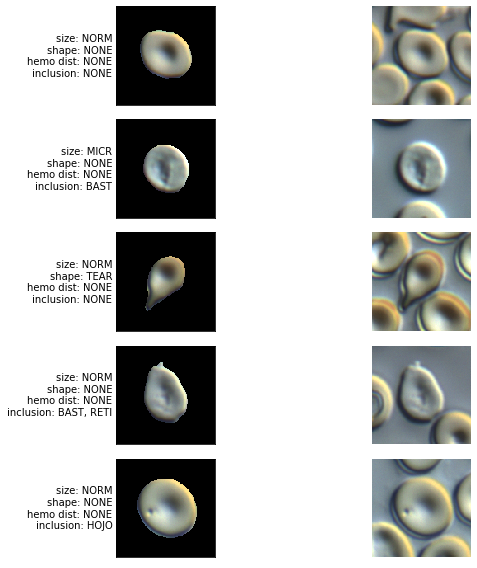

In [2]:
data_folder_center = 'data/good_images_center'
data_folder_full = 'data/good_images'

attributes = AttributesDataset('data/all_data_new_clean1.csv')

# transforms for train data(center and full crop)
to_tensor_trainset_center = transforms.Compose([transforms.ToTensor()])

to_tensor_trainset_full = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.4932, 0.5287, 0.5088), (0.1627, 0.1568, 0.1282))])        

# transforms for Val data(center and full crop)
to_tensor_testset_center = transforms.Compose([transforms.ToTensor()])
                             
to_tensor_testset_full = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.5023, 0.5367, 0.5102), (0.1692, 0.1617, 0.1303))])        

train_data = ClassificationDataset(data_folder_center, data_folder_full,'data/train_processed_new_clean1.csv',attributes,\
            to_tensor_center = to_tensor_trainset_center, to_tensor_full = to_tensor_trainset_full, aug_transforms = albumentation_transforms())

val_data = ClassificationDataset(data_folder_center, data_folder_full,'data/test_new_clean.csv', attributes, \
            to_tensor_center = to_tensor_testset_center, to_tensor_full = to_tensor_testset_full)

print("Train size: %i" % len(train_data))
print("Val size: %i" % len(val_data))
print("Center cell Img size: ", train_data[0]['img_center_cell'].size())
print("Full crop Img size: ", train_data[0]['img_full_crop'].size())
print("Concatenated Img size: ", train_data[0]['img'].size())

print('------------------------------------------------------------------------')

print("Size classes: ",attributes.size_labels)
print("Shape classes: ",attributes.shape_labels)
print("Hemoglobin distribution classes: ",attributes.hemo_dist_labels)
print("Inclusion classes: ",attributes.inclusion_labels)
print('------------------------------------------------------------------------')
# visualization.
num_example_imgs = 5
for i, dict_item in enumerate(train_data[0:num_example_imgs]):
    
    size_label = attributes.size_id_to_name[dict_item['labels']['size_label']]
    shape_label = attributes.shape_id_to_name[dict_item['labels']['shape_label']]
    hemo_dist_label = attributes.hemo_dist_id_to_name[dict_item['labels']['hemo_dist_label']]
    inclusion_label = np.array(attributes.inclusion_labels)[np.argwhere(dict_item['labels']['inclusion_label'] > 0)[:, 0]]
    label = "size: {}\nshape: {}\nhemo dist: {}\ninclusion: {}".format(size_label, shape_label, hemo_dist_label, ', '.join(inclusion_label))
 
    plt.subplot(num_example_imgs, 2, i * 2 + 1)
    img = dict_item['img_center_cell']
    plt.imshow(img.numpy().transpose(1,2,0))
    plt.xticks([])
    plt.yticks([])
    plt.ylabel(label, fontsize=10, rotation ='horizontal', ha ='right', va='center')
    
    plt.subplot(num_example_imgs, 2, i * 2 + 2)
    img = dict_item['img_full_crop']
    # unnormalize                              
    img[0] = img[0]*0.1627 + 0.4932
    img[1] = img[1]*0.1568 + 0.5287
    img[2] = img[2]*0.1282 + 0.5088
    plt.imshow(img.numpy().transpose(1,2,0))
    plt.axis('off')
plt.tight_layout() 
plt.show()

In [3]:
size, shape, hemo, inc_ones, inc_zeros = compute_class_weights(train_data, attributes)
size

{'MACR': 5.1231884057971016, 'MICR': 1.0, 'NORM': 0.14349502740004058}

Loaded pretrained weights for efficientnet-b7
START TRAIN.
Epoch  0  Train Loss  6.372690383874122 LR  0.0001  Val Loss  5.231861860010529
Epoch  1  Train Loss  4.359505210580383 LR  0.0001  Val Loss  4.163204087830988
Epoch  2  Train Loss  3.58284803768536 LR  0.0001  Val Loss  3.3218540403747907
Epoch  3  Train Loss  3.0249539188271335 LR  0.0001  Val Loss  2.8300051252283858
Epoch  4  Train Loss  2.569055233246241 LR  0.0001  Val Loss  2.7247370191522546
Epoch  5  Train Loss  2.2763317945675974 LR  0.0001  Val Loss  2.5513979682013685
Epoch  6  Train Loss  2.0729568748943357 LR  0.0001  Val Loss  2.4664212088490975
Epoch  7  Train Loss  1.8543835170386322 LR  0.0001  Val Loss  2.3067667899304336
Epoch  8  Train Loss  1.7268514176333687 LR  0.0001  Val Loss  2.372758466554136
Epoch  9  Train Loss  1.5755040272605643 LR  0.0001  Val Loss  2.019675912083806
Epoch  10  Train Loss  1.4725076703668385 LR  0.0001  Val Loss  1.7887343904647706
Epoch  11  Train Loss  1.3426405441323173 LR  0

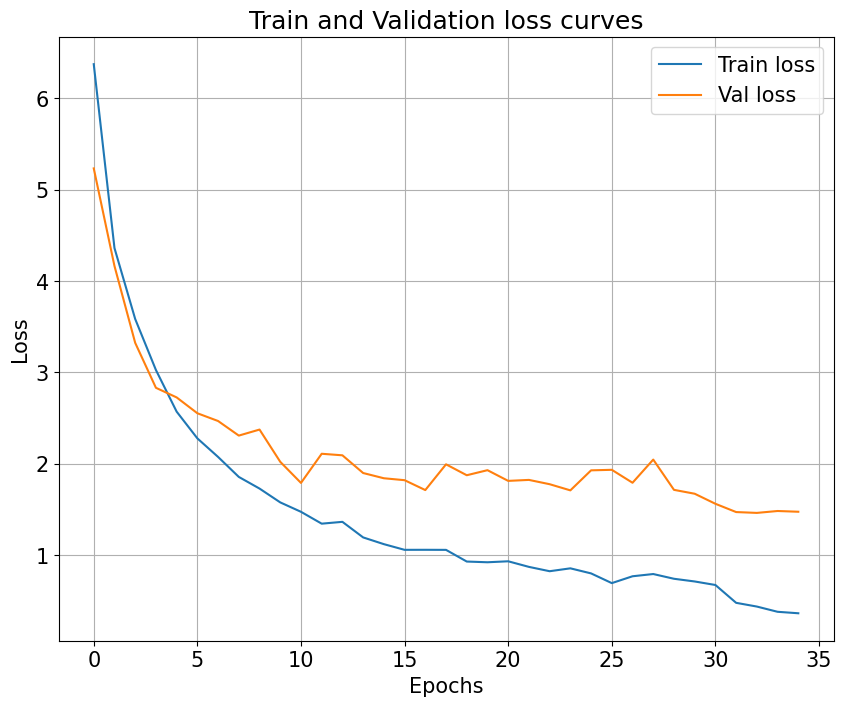

In [59]:
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=16, num_workers=1, shuffle=True)
                        
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=4, num_workers=1)

model = MultiOutputModel(size_classes = attributes.num_sizes, 
                         shape_classes = attributes.num_shapes, 
                         hemo_dist_classes = attributes.num_hemo_dist, 
                         inclusion_classes = attributes.num_inclusion).to(device)

solver = Solver(size, shape, hemo, inc_ones, inc_zeros)
                
solver.train(model, train_dataloader, val_dataloader, num_epochs=35)            #merged type input

In [61]:
model.save("models/merged_35_steplr_DIC_new_clean_simple_norm.model")     # merged

Saving model... models/merged_35_hemo_net_steplr_DIC_new_clean_simple_norm.model


In [5]:
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=16, num_workers=1, shuffle=True)
                        
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=4, num_workers=1)

model = torch.load("models/merged_35_steplr_DIC_new_clean_simple_norm.model").to(device)

solver = Solver(size, shape, hemo, inc_ones, inc_zeros)
model_predictions = solver.validate(model, val_dataloader) 

------------------------------------------------------------------------
Validation  accuracy size: 0.9231, shape: 0.9257, hemo_dist: 0.8393, inclusion: 0.9364



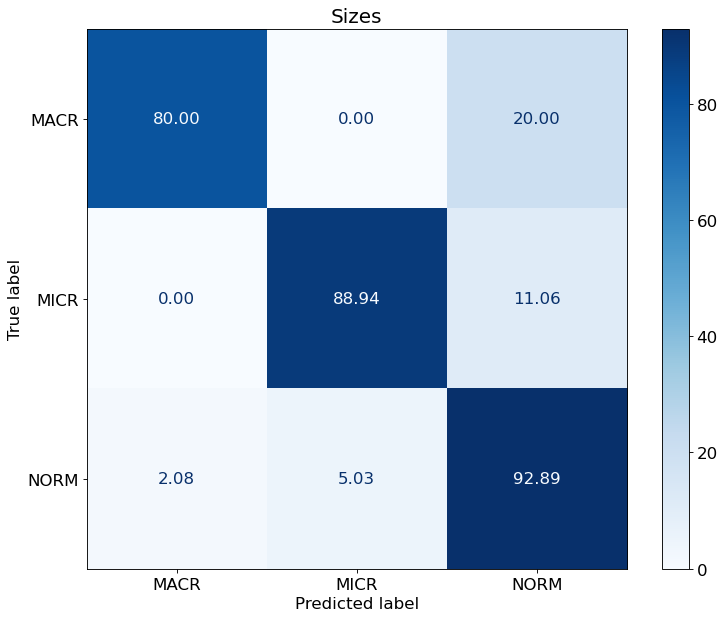

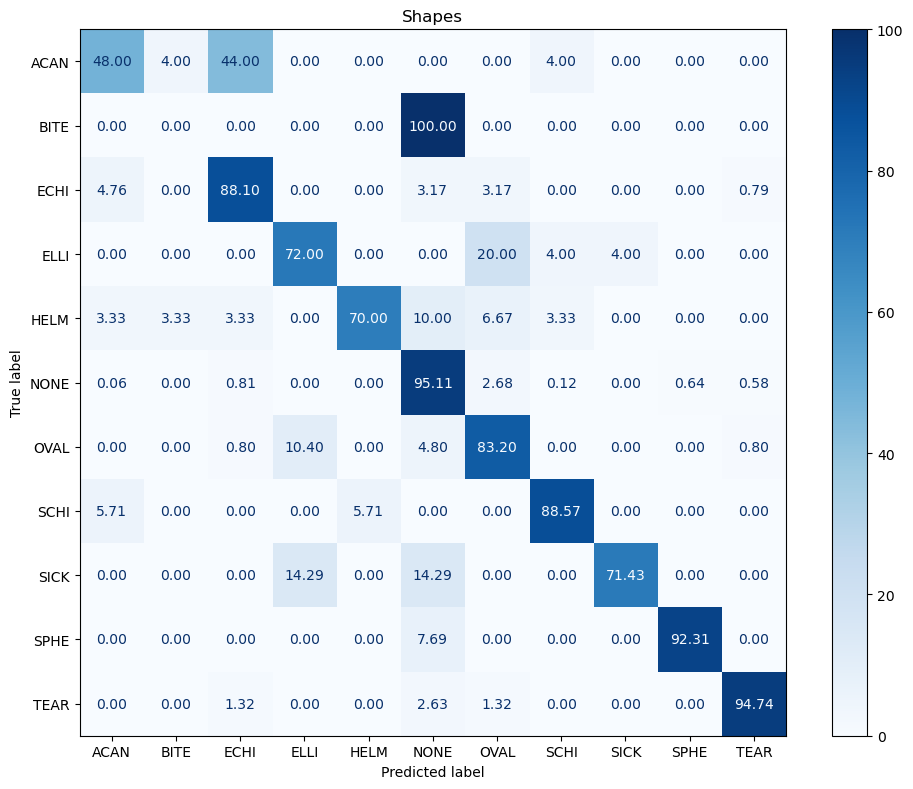

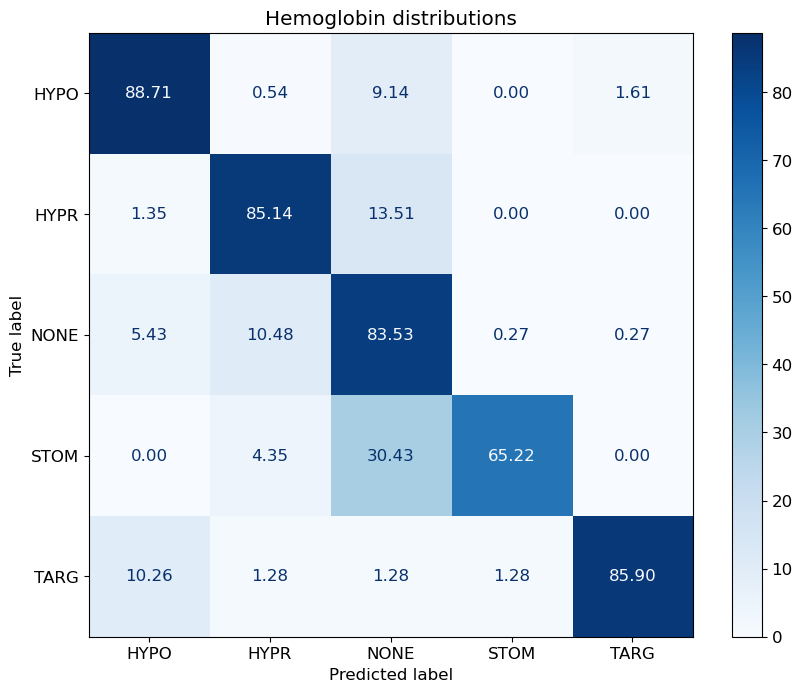

recall hemo [0.88709677 0.85135135 0.83534577 0.65217391 0.85897436]
f1_score hemo  [0.71895425 0.38066465 0.90085824 0.68181818 0.87581699]
[[[2150   11]
  [   7   15]]

 [[2145   22]
  [  10    6]]

 [[2131   22]
  [   4   26]]

 [[  99   31]
  [  53 2000]]

 [[2178    0]
  [   0    5]]

 [[2173    6]
  [   3    1]]

 [[2067   50]
  [  19   47]]]


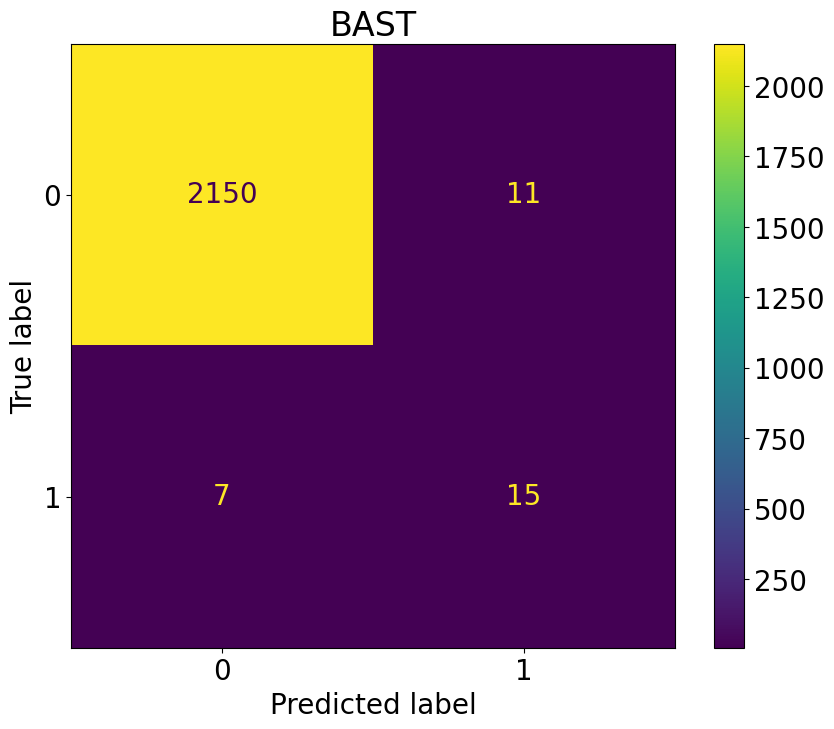

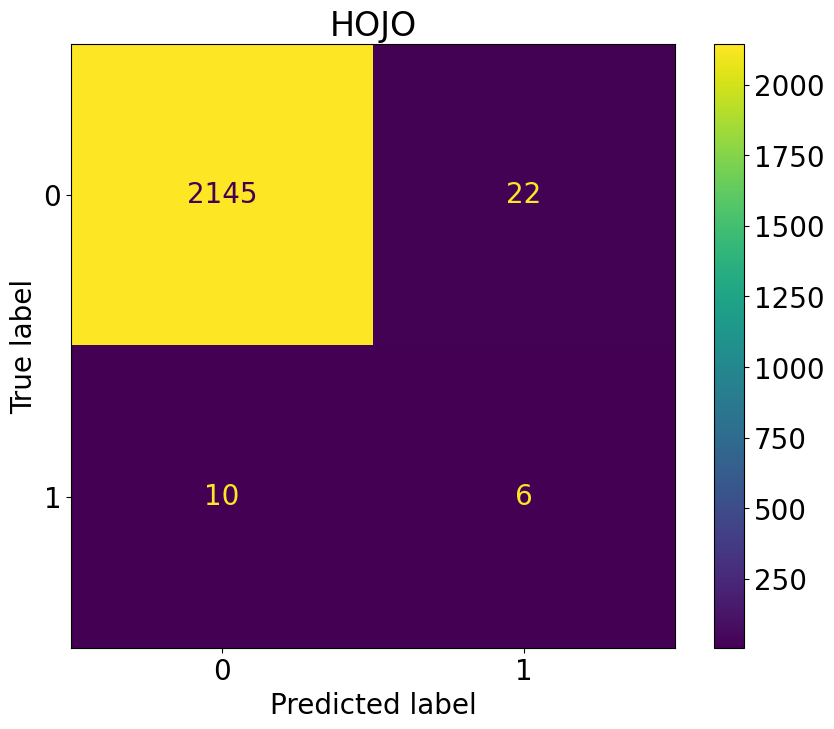

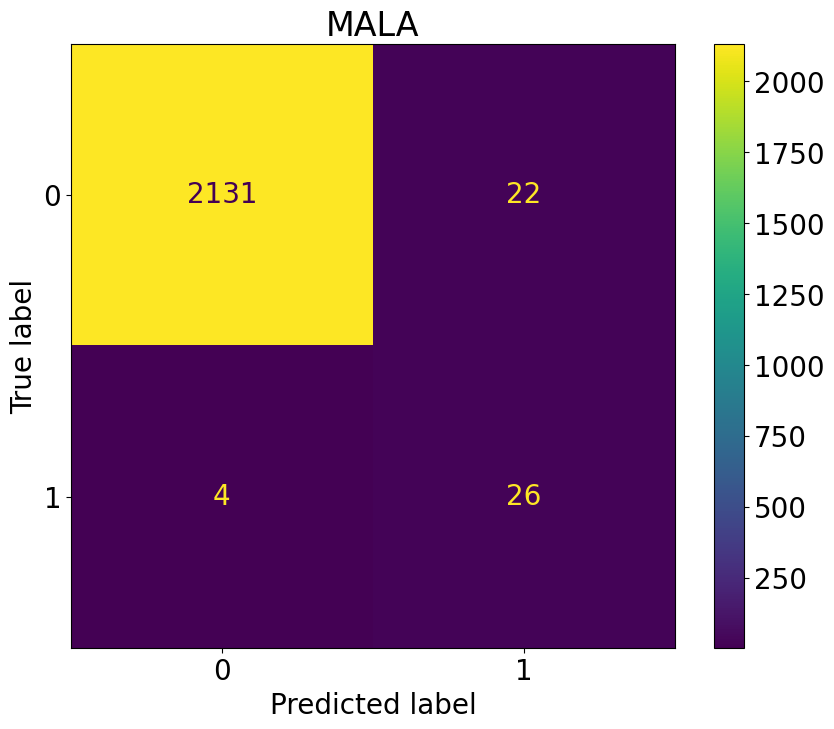

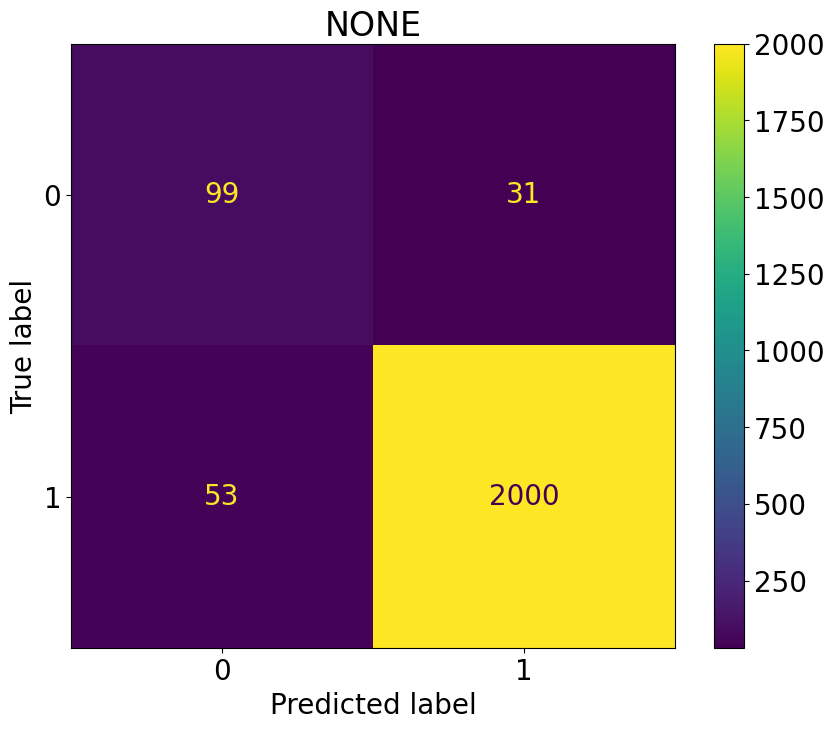

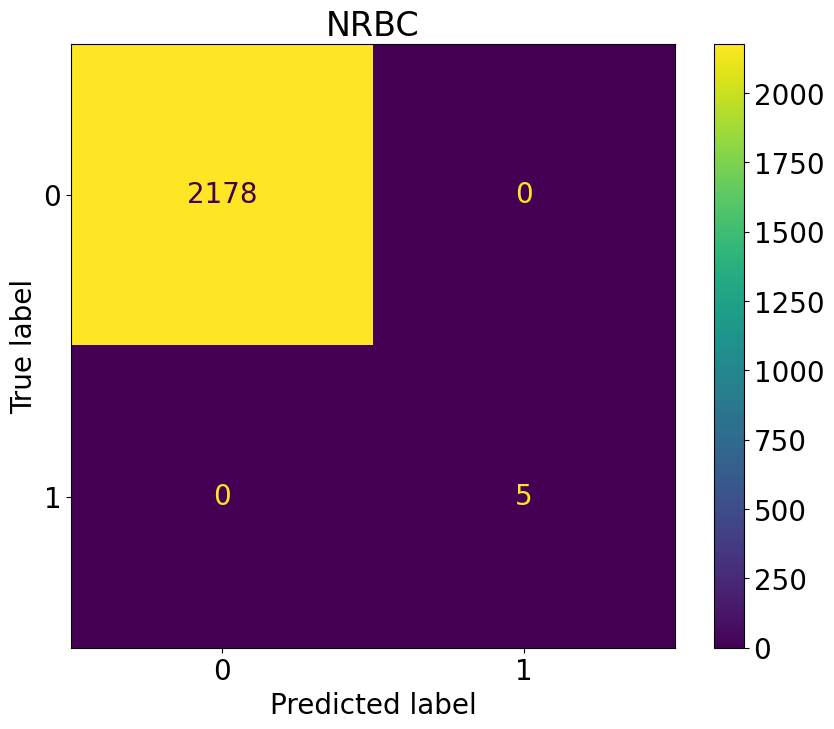

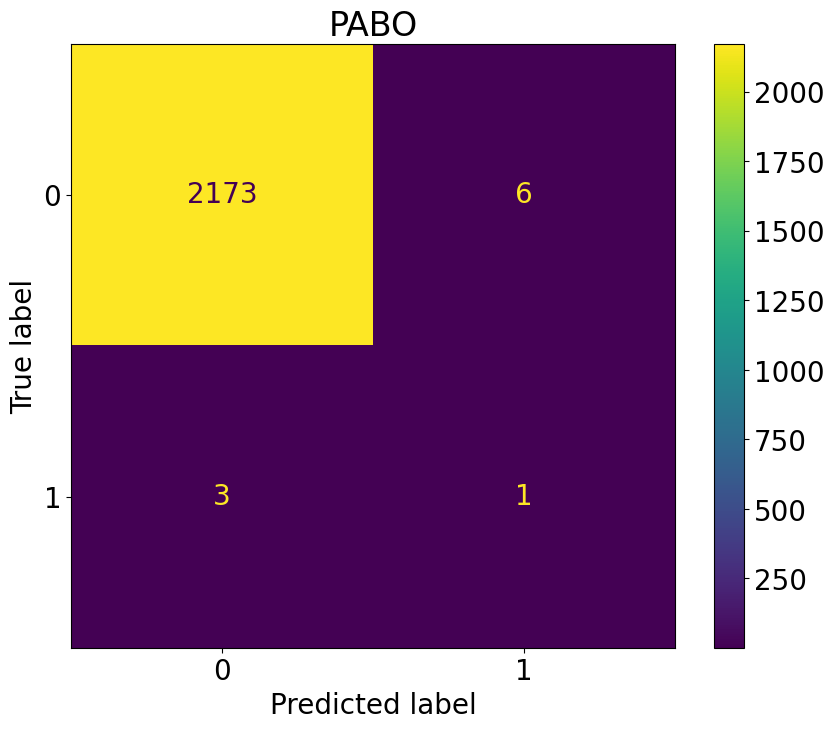

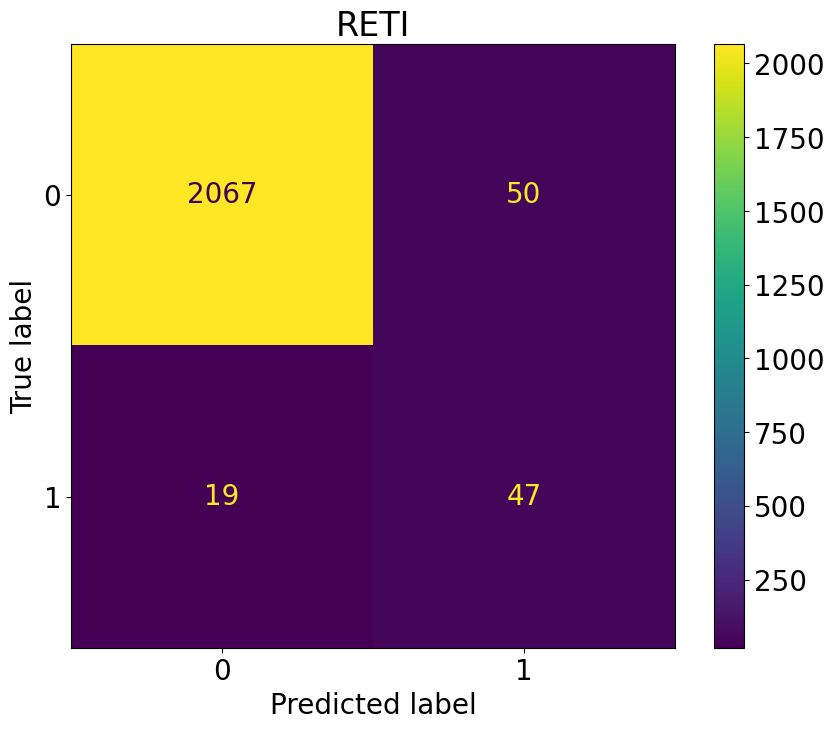

Metrics for Inclusions 
precision  [0.57692308 0.21428571 0.54166667 0.98473658 1.         0.14285714
 0.48453608]
recall  [0.68181818 0.375      0.86666667 0.97418412 1.         0.25
 0.71212121]
f1_score  [0.625      0.27272727 0.66666667 0.97943193 1.         0.18181818
 0.57668712]


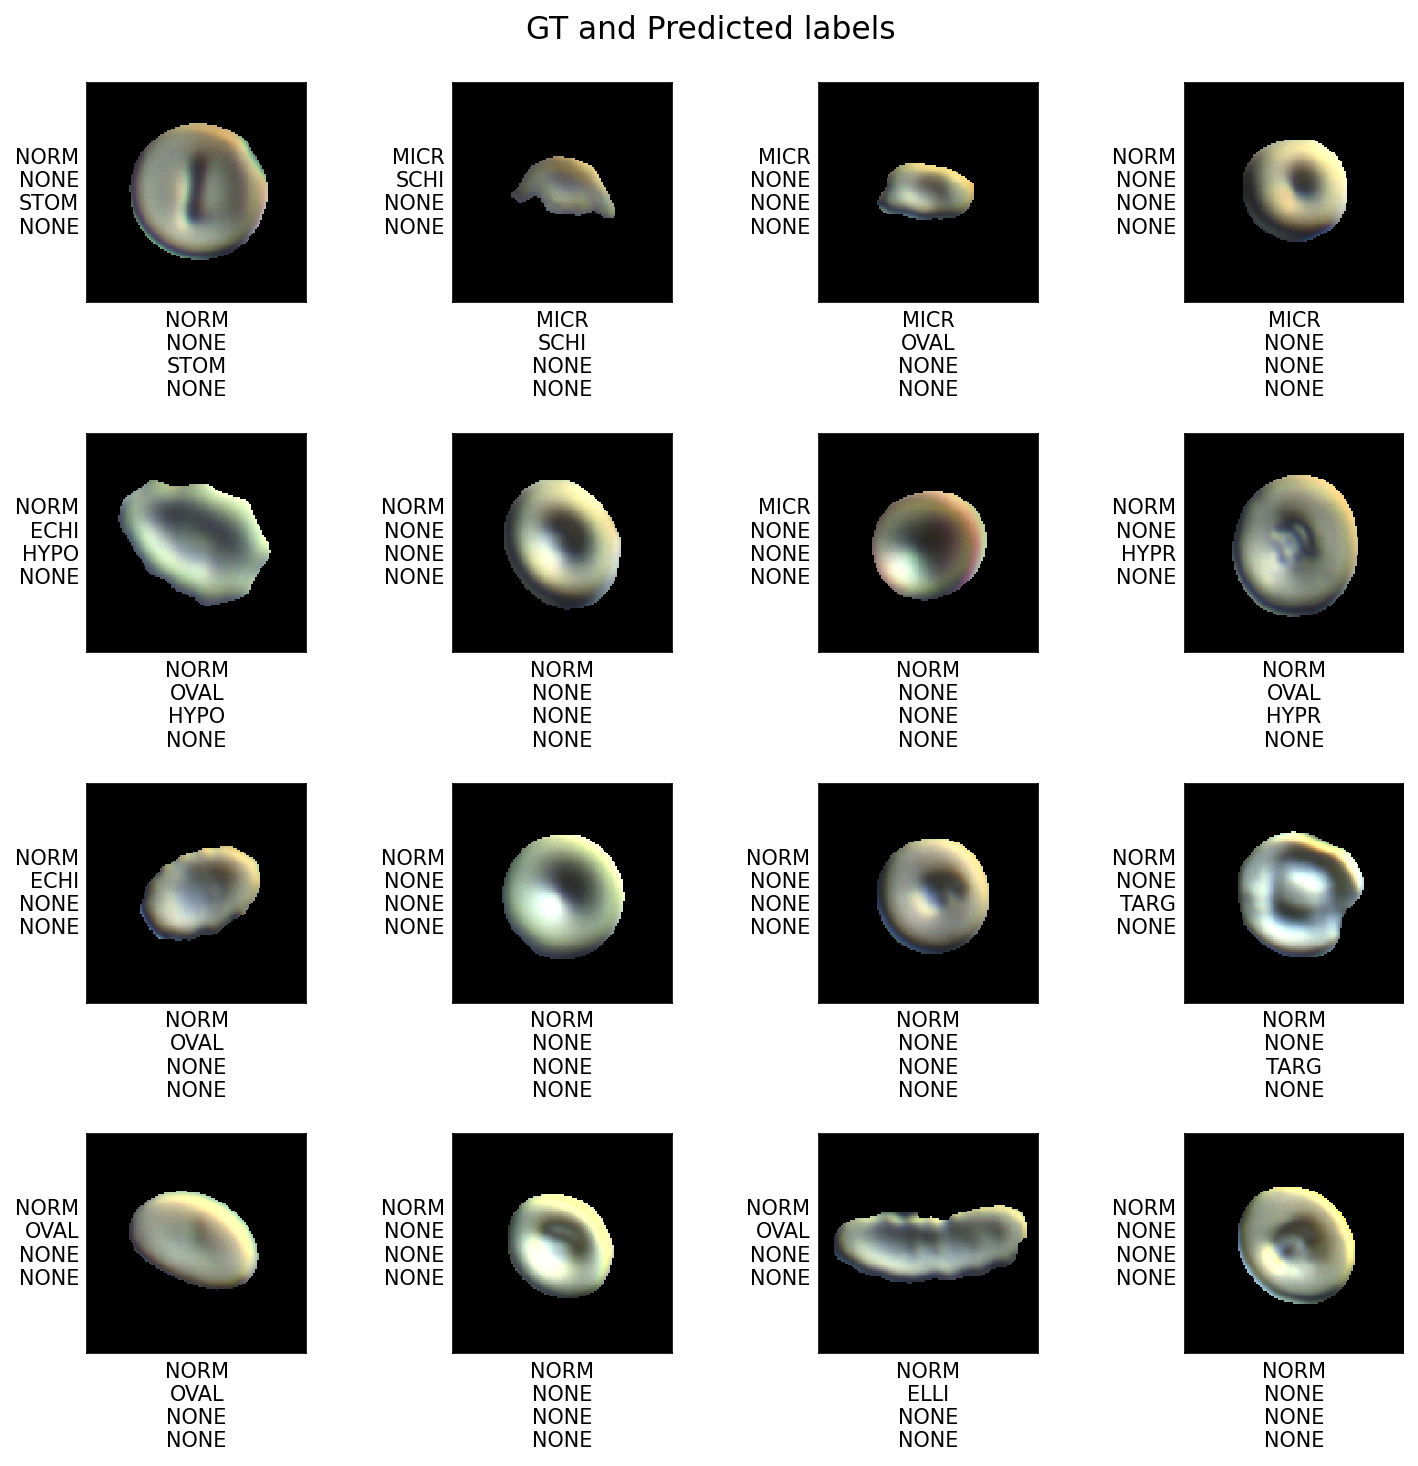

In [6]:
# Visualization of the trained model                                   
visualize_grid(val_data, attributes, *model_predictions) 